# DBSCAN & Hierarchical Clustering

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

### Table of Contents:


1. [Introduction](#intro)
2. [Section 1 — K-Mean Limitations](#section1)
3. [Section 2 — DBSCAN Algorithm](#section2)
4. [Section 3 — Hierarchical Clustering Algorithm](#section3)
5. [Section 4 — Hands-on Lap](#section4)
6. [References](#refs)

### Learning Objectives Of This Notebook
- Explain K-Means's limitations and when to prefer another method.
- Run DBSCAN and interpret its clusters and noise points.
-  Build and read a hierarchical clustering dendrogram, and choose a method per situation.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="intro"></a>
# Introduction



In the [previous notebook](https://github.com/thimarArda/BinX_AI_-_ML_Training/blob/main/Week5_Unsupervised_Learning/Day%201%20%E2%80%94%20Unsupervised%20Learning%20%26%20K-Means/Day%201%20%E2%80%94%20Unsupervised%20Learning%20%26%20K-Means.ipynb), we introduced **clustering algorithms** and focused on **K-Means Clustering**, including how it works and how to choose the appropriate number of clusters.

In this notebook, we will explore two additional clustering algorithms that can be used as alternatives to K-Means: **DBSCAN** and **Hierarchical Clustering**. These methods address some of the limitations of K-Means, such as its need to specify the number of clusters in advance and its difficulty handling irregularly shaped clusters and outliers.



<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section1"></a>
# Section 1 : K-Mean Limitations

K-Means is useful when the data forms relatively simple, compact groups, but it has some important limitations.

### Main limitations of K-Means

1. **Difficulty in Determining $K$**
   >  One of the drawbacks of the K-means algorithm is that we have to set the number of clusters ($K$) in advance. Choosing an incorrect number of clusters can lead to inaccurate results.
Various methods are available to estimate the optimal K, such as the silhouette analysis or elbow method, but they may not always provide a clear-cut answer.
If we use a too-small K, we’ll get too broad clusters. Conversely, an overlarge $K$ results in clusters that are too specific

2. **It works best with round or compact clusters**
   >  K-Means assigns points based on their distance from the centroid. Because of this, it works best when clusters are roughly circular or similarly shaped.

3. **It forces every point into a cluster**
  >  K-Means does not have a special category for noise or outliers. Even a point that is very far from all other points will still be assigned to one  of the clusters.

4.  **Sensitivity to Initial Conditions**
  > K-means is sensitive to initial conditions. The algorithm randomly initializes the cluster centroids at the beginning, and the final clustering results can vary depending on these initial positions. Different initializations can lead to other local optima, resulting in different clustering outcomes. This makes the K-means algorithm less reliable and reproducible.
> 
5.  **Inability to Handle Categorical Data**
   > Categorical data doesn’t have a natural notion of distance or similarity.
When categorical data is used with the `K-means` algorithm, it requires converting the categories into numerical values, such as using one-hot encoding. One shortcoming of using one-hot encoding is that it treats each feature independently and can degrade performance since it can significantly increase data dimensionality.
> 
6. **Time Complexity**
   > The time complexity of the algorithm is $O(n \times K \times M \times D)$, where $K$ is the number of clusters, $n$ is the number of data points, $D$ is the number of dimensions, and M is the number of iterations.

So, even moderately large datasets can be challenging to handle if they’re high-dimensional.
   
Because of these limitations, K-Means may not work well when the data contains:
- Irregularly shaped clusters
- Noise or outliers
- Clusters with different densities
- A number of clusters that is not known beforehand

Two algorithms that can help with these situations are **DBSCAN** and **Hierarchical Clustering**.

---

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section2"></a>
# Section 2 : DBSCAN Algorithm

### What is DBSCAN?

**DBSCAN** stands for **Density-Based Spatial Clustering of Applications with Noise**.
> Is a density-based clustering algorithm that groups data points that are closely packed together and marks outliers as noise based on their density in the feature space. **It identifies clusters as dense regions in the data space separated by areas of lower density**. Unlike K-Means or hierarchical clustering which assumes clusters are compact and spherical, DBSCAN perform well in handling real-world data irregularities such as:

- **Arbitrary-Shaped Clusters:** Clusters can take any shape not just circular or convex.
- **Noise and Outliers:** It effectively identifies and handles noise points without assigning them to any cluster.
 > <div style="text-align: center;"> <img src="DBSCAN.PNG" alt="how DBSCAN look " width="500" > </div>

The main idea is:
Instead of creating clusters around centroids like K-Means, DBSCAN looks at the **density of points**.
> Points that are close together and form a dense region are considered part of the same cluster, while isolated points in sparse regions can be treated as noise.

This gives DBSCAN two important advantages over K-Means:

- We do **not need to specify K** beforehand.
- DBSCAN can detect **irregularly shaped clusters** and identify **outliers/noise**.

### DBSCAN Code

```python
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X)

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section3"></a>
# Section 3 : Hierarchical Clustering Algorithm 

### What is Hierarchical Clustering?

> Hierarchical Clustering is an unsupervised learning technique that groups data into a hierarchy of clusters based on similarity. It builds a tree‑like structure (dendrogram) that helps visualize relationships and decide the optimal number of clusters.

### Dendrogram
A dendrogram is like a family tree for clusters. It shows how individual data points or groups of data merge together. The bottom shows each data point as its own group and as we move up, similar groups are combined.

The lower the merge point, the more similar the groups are. It helps us see how things are grouped step by step.
 
 > <div style="text-align: center;"> <img src="What-is-a-Dendrogram.png" alt="how Dendrogram look " width="500" > </div>

### Hierarchical Clustering — Code Syntax

Hierarchical Clustering can be implemented using `scipy.cluster.hierarchy`. The main steps are to create the cluster hierarchy and then visualize it using a dendrogram.

```python
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method="ward")
dendrogram(Z)
```

### Code Explanation

-  `linkage(X, method="ward")`  
  Builds the hierarchical clustering structure from the dataset `X`. The Ward method merges clusters while trying to keep the resulting clusters compact.

-  `Z`  
  Stores the information about how the points and clusters are progressively merged.

-  `dendrogram(Z)`  
  Visualizes the hierarchical clustering as a tree. The height of each merge represents the distance between the clusters being joined.

---

### Choosing the Number of Clusters

Unlike K-Means, we do not need to specify the number of clusters before building the hierarchy. Instead, we examine the dendrogram and choose a cutting height. The number of branches remaining below the chosen cut represents the number of clusters.

``` text
Dendrogram
    |
    |       ┌─────────────┐
    |   ┌───┤             │
    |   │   │             │
    | ┌─┤   │          ┌──┴──┐
    | │ │   │          │     │
    |____________________________
             ↑
          Cut here
```

For example, if the horizontal cut crosses 3 branches, the resulting clustering contains 3 clusters.

> **In simple terms:** `linkage()` builds the hierarchy, while `dendrogram()` allows us to visualize it and decide where to cut the hierarchy to obtain the desired number of clusters.          

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Which Algorithim To Choose ?

                 What does my data look like?
                           │
             ┌─────────────┴─────────────┐
             │                           │
       Compact/round?             Irregular/noisy?
             │                           │
            YES                         YES
             │                           │
         K-Means                    DBSCAN
             
             
       Want to see relationships
       and nested structure?
                 │
                YES
                 ↓
          Hierarchical



| Situation                        | Good choice                                               |
| -------------------------------- | --------------------------------------------------------- |
| Compact, round clusters          | **K-Means**                                               |
| You roughly know K               | **K-Means**                                               |
| Irregular-shaped clusters        | **DBSCAN**                                                |
| Many outliers/noise              | **DBSCAN**                                                |
| Don't know K                     | **DBSCAN / Hierarchical**                                 |
| Want a dendrogram                | **Hierarchical**                                          |
| Want to see nested relationships | **Hierarchical**                                          |
| Very large dataset               | **K-Means / DBSCAN** generally preferable to hierarchical |


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section4"></a>
# Section 4 : Hands-on Lap



In this section, we will implement ``DBSCAN`` and ``Hierarchical Clustering`` using the **Iris Dataset** from ``Scikit-learn``. We will then compare their results with the ``K-Means`` results from the previous notebook to understand how each algorithm identifies and groups patterns in the same dataset.


## Step 1: Run DBSCAN on the Day 1 dataset and report how many clusters and noise points it found

In [15]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler

dataset = load_iris()
dataset.keys()

#y = dataset.target
X_raw = dataset.data

# Put features into a DataFrame and scale
df_X = pd.DataFrame(X_raw, columns=dataset.feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_X)

# Convert back to DataFrame for cluster analysis
X_scaled_df = pd.DataFrame(X_scaled, columns=dataset.feature_names)

In [24]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X_scaled_df)
# label -1 marks noise / outlier points

print(labels)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


In [25]:
import numpy as np

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 34


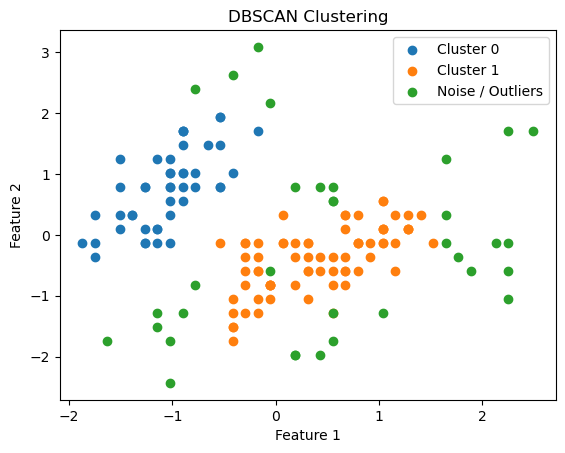

In [29]:
import matplotlib.pyplot as plt

unique_labels = set(labels)

for label in unique_labels:
    if label == -1:
        name = "Noise / Outliers"
    else:
        name = f"Cluster {label}"

    mask = labels == label

    plt.scatter(
        X_scaled_df.iloc[mask, 0],
        X_scaled_df.iloc[mask, 1],
        label=name
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

### DBSCAN Clustering Results

DBSCAN identified one clear cluster and another larger, more overlapping group, while also classifying some points as **noise**.

- **Cluster 1:** Mainly represents *Iris-Setosa*, which is clearly separated from the other flowers.
- **Cluster 2:** Contains the main group of *Versicolor* and *Virginica*, which have similar and overlapping features.
- **Noise (-1):** Some points were not dense enough to belong to a cluster, so DBSCAN classified them as noise.

This happens because *Versicolor* and *Virginica* overlap in the feature space. DBSCAN cannot find a clear density gap between them, so some boundary points are treated as noise instead of forming a separate cluster.

This is a similar labeling as the [k-mean from day 1 notebook](https://github.com/thimarArda/BinX_AI_-_ML_Training/blob/main/Week5_Unsupervised_Learning/Day%201%20%E2%80%94%20Unsupervised%20Learning%20%26%20K-Means/Day%201%20%E2%80%94%20Unsupervised%20Learning%20%26%20K-Means.ipynb)

--------

## Step 2: Build a hierarchical clustering dendrogram and choose a cut height, noting the resulting cluster count.

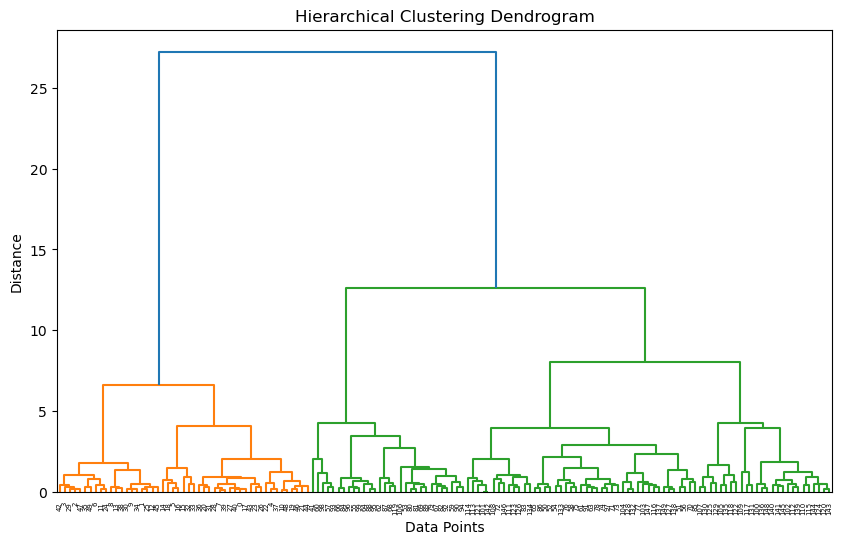

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_scaled_df, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Hierarchical Clustering Dendrogram Analysis

The dendrogram suggests that the data can reasonably be divided into **2 or 3 clusters**, depending on where we cut the tree.

- **2 clusters (The left tree):** Cutting the dendrogram at a higher distance level separates the data into two main groups.
- **3 clusters (The right tree):** Cutting it at a lower distance level further splits one of the main groups, giving us three clusters.

The **3-cluster solution is closer to the Iris dataset because it matches the three known flower species: Setosa, Versicolor, and Virginica.**

> the dendrogram shows that the data has a clear main separation, while one of the groups can be further divided into two smaller groups.


---------

## Step 3: Compare the K-Means, DBSCAN, and hierarchical results on the same data.

| Algorithm | Output | Interpretation |
| --- | --- | --- |
| **K-Means** | **2 clusters** | Setosa was clearly separated, while Versicolor and Virginica were grouped together because their features overlap. |
| **Hierarchical** | **2 main clusters or 3 sub-clusters** | The dendrogram shows a clear main split, while a lower cut separates the data into 3 groups, matching the three Iris species. |
| **DBSCAN** | **2 clusters + noise points** | Setosa formed a clear dense cluster, while the overlapping Versicolor and Virginica were mostly grouped together. Some boundary points were classified as noise because they did not meet the density requirement. |

--------

## Step 4: In Markdown, state which method best fits this dataset's shape and why.

For this dataset, **K-Means and Hierarchical Clustering perform better than DBSCAN**.
The Iris data contains relatively compact groups, and *Iris-Setosa* is clearly separated. However, *Versicolor* and *Virginica* have overlapping features, making it difficult for DBSCAN to separate them based on density.

**K-Means is a good choice for this dataset**, while **Hierarchical Clustering is also useful because its dendrogram reveals both the main 2-group structure and the possible 3-group structure.**



<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="refs"></a>
# References

- Limitaion of K-Means : https://www.baeldung.com/cs/k-means-flaws-improvements
-  Clustering Into an Unknown Number of Clusters : https://www.baeldung.com/cs/clustering-unknown-number
-  DBSCAN Algorithm :
      - https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/
      - https://www.baeldung.com/cs/clustering-unknown-number    